# $\textbf{Final Project — Maternal Health Risk Hybrid Expert System}$
### $\textit{Pipeline:}\;\; \text{Patient} \;\to\; NN_1 \;\to\; NN_2 \;\to\; \text{Expert System (CF)} \;\to\; \text{Diagnosis}$


## $1.$ ***Importing Libraries & Data***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
data = pd.read_csv('data/Maternal Health Risk Data Set.csv')

## $2.$ ***Exploring Data***

In [3]:
data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
data.shape

(1014, 7)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [6]:
data.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [7]:
data['RiskLevel'].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [8]:
numerical_columns   = list(set(data.select_dtypes(include='number').columns))
categorical_columns = list(set(data.columns) - set(numerical_columns))

print('numerical   :', numerical_columns)
print('categorical :', categorical_columns)

numerical   : ['DiastolicBP', 'HeartRate', 'BS', 'BodyTemp', 'SystolicBP', 'Age']
categorical : ['RiskLevel']


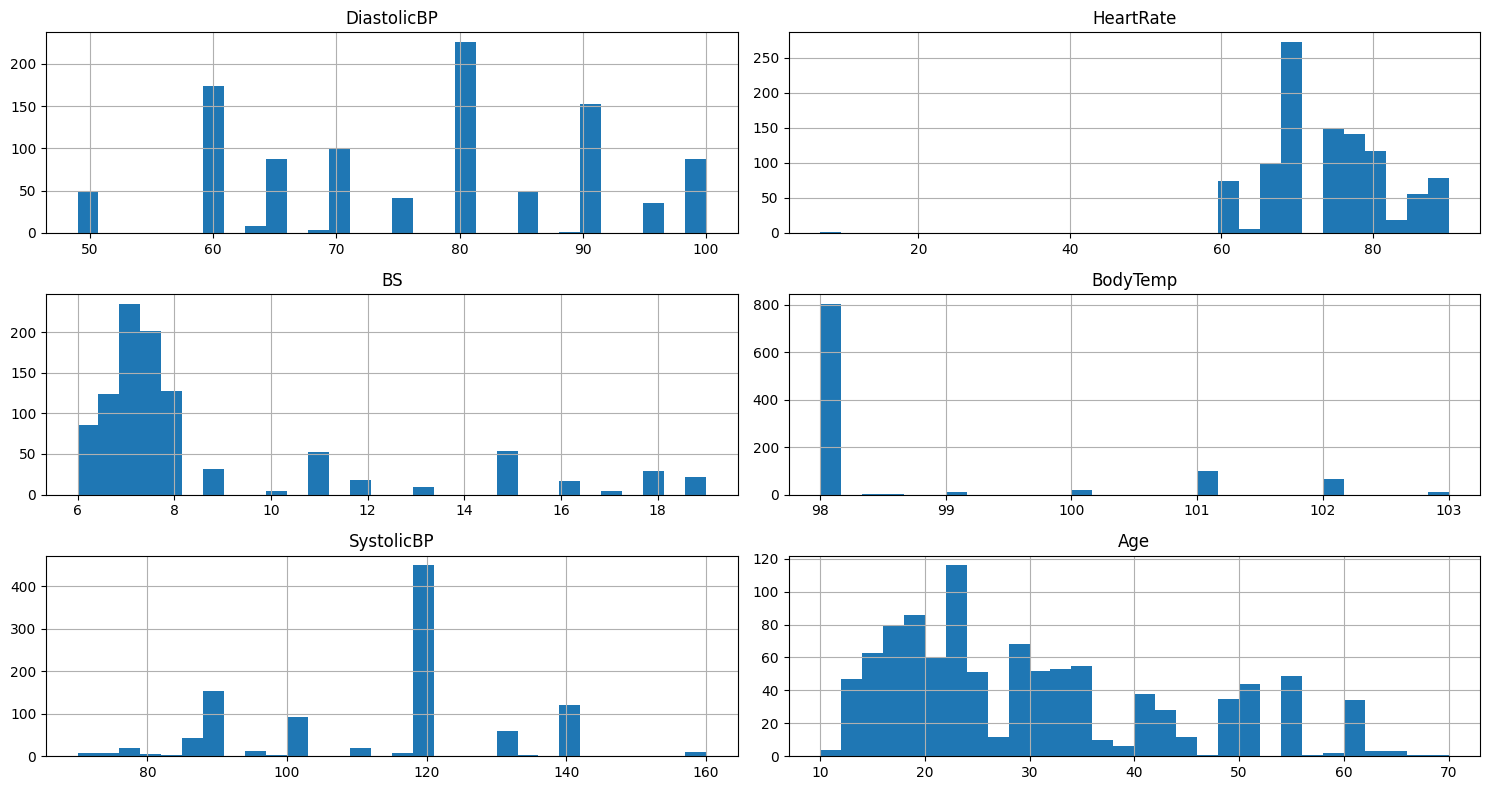

In [9]:
data[numerical_columns].hist(bins=30, figsize=(15, 8))
plt.tight_layout()
plt.show()

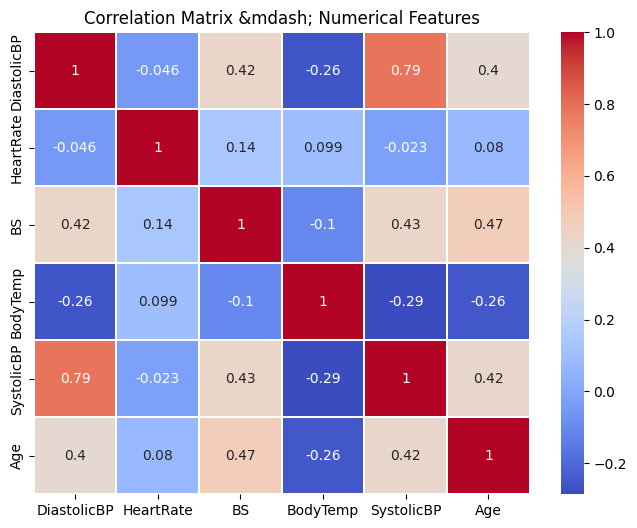

In [10]:
corr_matrix = data[numerical_columns].corr()
plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.1)
plt.title('Correlation Matrix &mdash; Numerical Features')
plt.show()

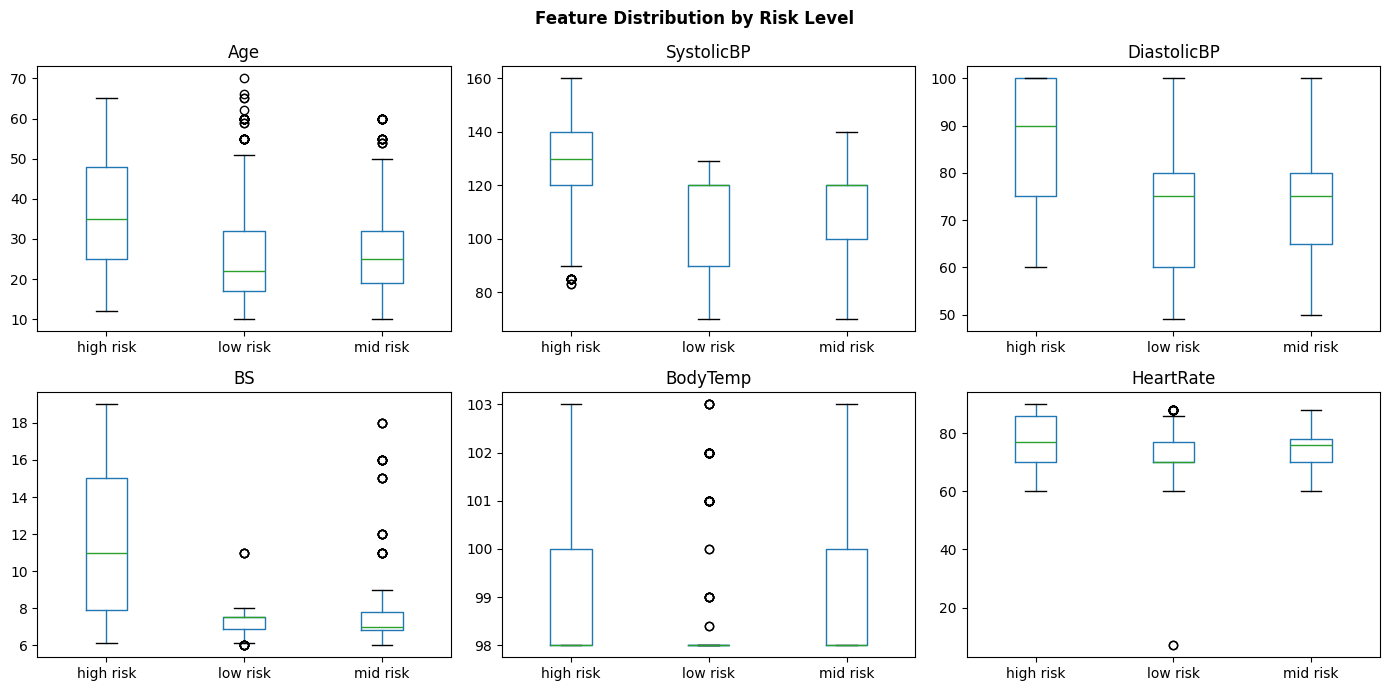

In [11]:
features = ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, features):
    data.boxplot(column=feat, by='RiskLevel', ax=ax, grid=False)
    ax.set_title(feat); ax.set_xlabel('')
plt.suptitle('Feature Distribution by Risk Level', fontweight='bold')
plt.tight_layout()
plt.show()

## $3.$ ***Handling Null Values***

In [12]:
nulls_df = data.isna().sum().reset_index().rename(columns={0:'Nulls_Count'})
nulls_df[nulls_df['Nulls_Count']>0].sort_values(by=['Nulls_Count'], ascending=False)

,index,Nulls_Count


## $4.$ ***Outliers &mdash; IQR Clamping***

$IQR = Q_3 - Q_1$&emsp;&emsp;Lower $= Q_1 - 1.5\cdot IQR$&emsp;&emsp;Upper $= Q_3 + 1.5\cdot IQR$

In [13]:
def Clamping_Outliers(df, Target_Columns, threshold=1.5):
    for col in Target_Columns:
        df[col] = df[col].astype(float)

        Q1 = np.percentile(df[col], 25)
        Q3 = np.percentile(df[col], 75)

        IQR = Q3 - Q1

        Upper = Q3 + threshold * IQR
        Lower = Q1 - threshold * IQR

        df.loc[df[col] < Lower, col] = Lower
        df.loc[df[col] > Upper, col] = Upper
    return df

In [14]:
clamp_bounds = {}
for col in features:
    Q1 = np.percentile(data[col], 25)
    Q3 = np.percentile(data[col], 75)
    IQR = Q3 - Q1
    clamp_bounds[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)

data = Clamping_Outliers(data, features)
clamp_bounds

{'Age': (np.float64(-11.0), np.float64(69.0)),
 'SystolicBP': (np.float64(70.0), np.float64(150.0)),
 'DiastolicBP': (np.float64(27.5), np.float64(127.5)),
 'BS': (np.float64(5.250000000000001), np.float64(9.649999999999999)),
 'BodyTemp': (np.float64(98.0), np.float64(98.0)),
 'HeartRate': (np.float64(55.0), np.float64(95.0))}

## $5.$ ***Skewness***

$Z = \dfrac{x - \mu}{\sigma}$&emsp;&emsp;Transform with $\;Y = \operatorname{sign}(x)\cdot\log(1 + |x|)\;$ where $|skew| > 1$.

In [15]:
def Skewness_calculator(df: pd.DataFrame, Target_columns: list):
    means = df[Target_columns].mean(axis=0)
    stds  = df[Target_columns].std(axis=0)
    skewness_dictionary = (((df[Target_columns] - means)**3).sum(axis=0)) / ((df.shape[0] - 1) * stds**3)
    return skewness_dictionary

In [16]:
def Skewness_transformation(df: pd.DataFrame, Target_columns: list, threshold: float = 1.0):
    skewness_val = Skewness_calculator(df, Target_columns)
    transformed  = []
    for col, sk in skewness_val.items():
        if abs(sk) > threshold:
            df[col] = np.sign(df[col]) * np.log1p(df[col].abs())
            transformed.append(col)
            print(f"column {col} is transformed (skewness={sk:+.3f})")
    return df, transformed

In [17]:
data, skewed_columns = Skewness_transformation(data, features, threshold=1.0)
print('\nlog-transformed columns:', skewed_columns)


log-transformed columns: []


In [18]:
Skewness_calculator(data, features)

Age            0.780342
SystolicBP    -0.330441
DiastolicBP   -0.048345
BS             0.684170
BodyTemp            NaN
HeartRate      0.046803
dtype: float64

## $6.$ ***Encoding the Target***

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y  = le.fit_transform(data['RiskLevel'])
print('classes  :', list(le.classes_))
print('encoded  :', list(range(len(le.classes_))))

classes  : ['high risk', 'low risk', 'mid risk']
encoded  : [0, 1, 2]


In [20]:
X = data.drop('RiskLevel', axis=1)
X.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25.0,130.0,80.0,9.65,98.0,86.0
1,35.0,140.0,90.0,9.65,98.0,70.0
2,29.0,90.0,70.0,8.00,98.0,80.0
3,30.0,140.0,85.0,7.00,98.0,70.0
4,35.0,120.0,60.0,6.10,98.0,76.0


## $7.$ ***Feature Scaling***

*We use $Z$-score standardization on the 6 vitals.*

In [21]:
def Standardization_Z_Score(df: pd.DataFrame, Target_Columns: list):
    for col in Target_Columns:
        df[col] = ((df[col] - df[col].mean()) / df[col].std())
    return df

In [22]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,-0.361743,0.930174,0.255023,1.700156,0.0,1.534850
1,0.380932,1.480559,0.975539,1.700156,0.0,-0.581537
2,-0.064673,-1.271369,-0.465493,0.250676,0.0,0.741205
3,0.009595,1.480559,0.615281,-0.627796,0.0,-0.581537
4,0.380932,0.379788,-1.186009,-1.418421,0.0,0.212108


## $8.$ ***Train-Test Split (Stratified)***

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y,
)

print(f"train set : {X_train.shape[0]} patients")
print(f"test  set : {X_test.shape[0]} patients")

train set : 811 patients
test  set : 203 patients


## $9.$ ***Hybrid Architecture: $NN_1 \to NN_2 \to$ Expert System***

```
patient → scaler → NN_1 → [P_low, P_mid, P_high]
                    │
                    ▼  concat(scaled features, NN_1 probs)
                  NN_2 → refined [P_low, P_mid, P_high]
                    │
                    ▼  P(high) is the seed CF
                Expert System (CF rules)
                    │
                    ▼
                final diagnosis
```

## $9.1.$ ***$NN_1$ &mdash; Stage-1 Classifier***

In [24]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

architectures = [(8,), (16,), (16, 8), (32, 16)]

In [25]:
print(f"{'architecture':<14} | {'test acc':<10} | iterations")
print('-' * 44)

results_nn1 = {}
for arch in architectures:
    nn = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
    nn.fit(X_train, y_train)
    acc = accuracy_score(y_test, nn.predict(X_test))
    results_nn1[arch] = (acc, nn.n_iter_)
    print(f"{str(arch):<14} | {acc:<10.4f} | {nn.n_iter_}")

best_arch_nn1 = max(results_nn1, key=lambda a: results_nn1[a][0])
print(f"\nbest NN_1 architecture: {best_arch_nn1}  (acc={results_nn1[best_arch_nn1][0]:.4f})")

architecture   | test acc   | iterations
--------------------------------------------
(8,)           | 0.6355     | 445
(16,)          | 0.6650     | 509
(16, 8)        | 0.6749     | 561
(32, 16)       | 0.7291     | 658

best NN_1 architecture: (32, 16)  (acc=0.7291)


In [26]:
nn1 = MLPClassifier(
    hidden_layer_sizes = best_arch_nn1,
    activation         = 'relu',
    solver             = 'adam',
    learning_rate_init = 0.001,
    max_iter           = 1000,
    random_state       = 42,
)
nn1.fit(X_train, y_train)
print(f"NN_1 final loss : {nn1.loss_:.4f}   iterations : {nn1.n_iter_}")

NN_1 final loss : 0.4920   iterations : 658


In [27]:
y_pred_nn1 = nn1.predict(X_test)
print(f"NN_1 test accuracy : {accuracy_score(y_test, y_pred_nn1):.4f}\n")
print(classification_report(y_test, y_pred_nn1, target_names=le.classes_))

NN_1 test accuracy : 0.7291

              precision    recall  f1-score   support

   high risk       0.96      0.87      0.91        55
    low risk       0.69      0.72      0.70        81
    mid risk       0.61      0.63      0.62        67

    accuracy                           0.73       203
   macro avg       0.75      0.74      0.74       203
weighted avg       0.74      0.73      0.73       203



## $9.2.$ ***$NN_2$ &mdash; Stage-2 Refiner***

*Input* $= [\,\text{scaled vitals}\,\Vert\,NN_1\text{ probs}\,]\;\;(6 + 3 = 9\text{ features})$.

In [28]:
nn1_probs_train = nn1.predict_proba(X_train)
nn1_probs_test  = nn1.predict_proba(X_test)

X_train_stage2 = np.hstack([X_train, nn1_probs_train])
X_test_stage2  = np.hstack([X_test,  nn1_probs_test])

print(f"NN_1 prob shape : {nn1_probs_train.shape}")
print(f"NN_2 input shape: {X_train_stage2.shape}")

NN_1 prob shape : (811, 3)
NN_2 input shape: (811, 9)


In [29]:
print(f"{'architecture':<14} | {'test acc':<10} | iterations")
print('-' * 44)

results_nn2 = {}
for arch in architectures:
    nn = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
    nn.fit(X_train_stage2, y_train)
    acc = accuracy_score(y_test, nn.predict(X_test_stage2))
    results_nn2[arch] = (acc, nn.n_iter_)
    print(f"{str(arch):<14} | {acc:<10.4f} | {nn.n_iter_}")

best_arch_nn2 = max(results_nn2, key=lambda a: results_nn2[a][0])
print(f"\nbest NN_2 architecture: {best_arch_nn2}  (acc={results_nn2[best_arch_nn2][0]:.4f})")

architecture   | test acc   | iterations
--------------------------------------------
(8,)           | 0.7044     | 487
(16,)          | 0.7044     | 349
(16, 8)        | 0.7044     | 314
(32, 16)       | 0.7143     | 270

best NN_2 architecture: (32, 16)  (acc=0.7143)


In [30]:
nn2 = MLPClassifier(
    hidden_layer_sizes = best_arch_nn2,
    activation         = 'relu',
    solver             = 'adam',
    learning_rate_init = 0.001,
    max_iter           = 1000,
    random_state       = 42,
)
nn2.fit(X_train_stage2, y_train)
print(f"NN_2 final loss : {nn2.loss_:.4f}   iterations : {nn2.n_iter_}")

NN_2 final loss : 0.4435   iterations : 270


In [31]:
y_pred_nn2 = nn2.predict(X_test_stage2)
print(f"NN-chain test accuracy : {accuracy_score(y_test, y_pred_nn2):.4f}\n")
print(classification_report(y_test, y_pred_nn2, target_names=le.classes_))

NN-chain test accuracy : 0.7143

              precision    recall  f1-score   support

   high risk       0.96      0.87      0.91        55
    low risk       0.65      0.78      0.71        81
    mid risk       0.61      0.51      0.55        67

    accuracy                           0.71       203
   macro avg       0.74      0.72      0.72       203
weighted avg       0.72      0.71      0.71       203



## $9.3.$ ***NN-Chain Diagnostics***

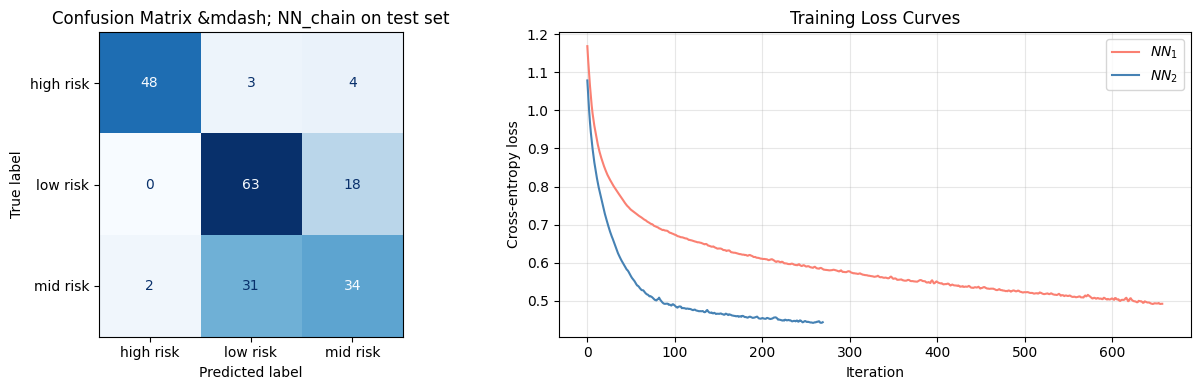

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nn2,
    display_labels = le.classes_,
    cmap = 'Blues', ax = ax1, colorbar = False,
)
ax1.set_title("Confusion Matrix &mdash; NN_chain on test set")

ax2.plot(nn1.loss_curve_, color='salmon',    linewidth=1.5, label='$NN_1$')
ax2.plot(nn2.loss_curve_, color='steelblue', linewidth=1.5, label='$NN_2$')
ax2.set_title("Training Loss Curves")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Cross-entropy loss")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## $10.$ ***Expert System &mdash; Certainty Factors***

$\;\;total\_cf = total\_cf + cf \cdot (1 - total\_cf)$

In [33]:
cf_rules = {
    'high_bp'    : 0.70,
    'high_sugar' : 0.65,
    'fever'      : 0.40,
    'fast_heart' : 0.50,
    'older_mom'  : 0.30,
}


def check_rules(patient: dict) -> dict:
    return {
        'high_bp'    : bool(patient['SystolicBP'] >= 140 or patient['DiastolicBP'] >= 90),
        'high_sugar' : bool(patient['BS']         >= 11),
        'fever'      : bool(patient['BodyTemp']   >= 100),
        'fast_heart' : bool(patient['HeartRate']  >= 90),
        'older_mom'  : bool(patient['Age']        >= 35),
    }


def combine_cf(cf1: float, cf2: float) -> float:
    return cf1 + cf2 * (1 - cf1)

## $11.$ ***Hybrid Pipeline &mdash; `diagnose()`***

In [34]:
HIGH_IDX      = list(le.classes_).index('high risk')
FEATURE_ORDER = list(X.columns)


def preprocess_patient(patient: dict, skewed_cols=None, scaler=scaler):
    if skewed_cols is None:
        skewed_cols = skewed_columns
    row = pd.DataFrame([patient])[FEATURE_ORDER].astype(float).copy()
    for col in skewed_cols:
        row[col] = np.sign(row[col]) * np.log1p(row[col].abs())
    return scaler.transform(row)


def diagnose(patient: dict, scaler=scaler, nn1=nn1, nn2=nn2, le=le, cf_rules=cf_rules):
    scaled = preprocess_patient(patient, skewed_columns, scaler)

    p1 = nn1.predict_proba(scaled)

    stage2 = np.hstack([scaled, p1])
    p2     = nn2.predict_proba(stage2)[0]
    nn_cf  = float(p2[HIGH_IDX])

    total_cf = nn_cf
    chain = [('NN_chain P(high)', nn_cf)]
    for rule_name, present in check_rules(patient).items():
        if present:
            cf       = cf_rules[rule_name]
            total_cf = combine_cf(total_cf, cf)
            chain.append((f'rule: {rule_name}', cf))

    if   total_cf >= 0.70: verdict = 'Likely HIGH risk'
    elif total_cf >= 0.40: verdict = 'Possibly MID risk'
    else                 : verdict = 'Likely LOW risk'

    return {
        'verdict'    : verdict,
        'final_cf'   : round(total_cf, 4),
        'nn_cf'      : round(nn_cf,    4),
        'nn_probs'   : {cls: round(float(p), 4) for cls, p in zip(le.classes_, p2)},
        'rules_fired': chain[1:],
        'chain'      : chain,
    }

In [35]:
def print_report(patient, result):
    print('=' * 64)
    print('  PATIENT INPUT')
    for k, v in patient.items():
        print(f'     {k:<13}: {v}')
    print('-' * 64)
    print('  NN_2 PROBABILITIES')
    for cls, p in result['nn_probs'].items():
        print(f'     P({cls:<10}) = {p:.4f}')
    print('-' * 64)
    print('  CHAIN OF EVIDENCE')
    running = 0.0
    for i, (name, cf) in enumerate(result['chain']):
        running = cf if i == 0 else combine_cf(running, cf)
        print(f'     + {name:<22} cf={cf:.3f}   running={running:.3f}')
    print('-' * 64)
    print(f"  FINAL CF  : {result['final_cf']:.4f}")
    print(f"  DIAGNOSIS : {result['verdict']}")
    print('=' * 64)

In [36]:
raw_data = pd.read_csv('data/Maternal Health Risk Data Set.csv')

for risk in ['high risk', 'mid risk', 'low risk']:
    sample  = raw_data[raw_data['RiskLevel'] == risk].sample(1, random_state=2026).iloc[0]
    patient = sample.drop('RiskLevel').to_dict()
    print(f"\n>>> ground-truth label: {risk}")
    print_report(patient, diagnose(patient))


>>> ground-truth label: high risk
  PATIENT INPUT
     Age          : 12
     SystolicBP   : 90
     DiastolicBP  : 60
     BS           : 7.9
     BodyTemp     : 102.0
     HeartRate    : 66
----------------------------------------------------------------
  NN_2 PROBABILITIES
     P(high risk ) = 0.9711
     P(low risk  ) = 0.0242
     P(mid risk  ) = 0.0047
----------------------------------------------------------------
  CHAIN OF EVIDENCE
     + NN_chain P(high)       cf=0.971   running=0.971
     + rule: fever            cf=0.400   running=0.983
----------------------------------------------------------------
  FINAL CF  : 0.9827
  DIAGNOSIS : Likely HIGH risk

>>> ground-truth label: mid risk
  PATIENT INPUT
     Age          : 17
     SystolicBP   : 90
     DiastolicBP  : 60
     BS           : 6.9
     BodyTemp     : 101.0
     HeartRate    : 76
----------------------------------------------------------------
  NN_2 PROBABILITIES
     P(high risk ) = 0.0289
     P(low risk  ) 

## $12.$ ***Saving the Model***

In [37]:
preprocess_meta = {
    'feature_order'  : FEATURE_ORDER,
    'skewed_columns' : skewed_columns,
    'clamp_bounds'   : clamp_bounds,
    'cf_rules'       : cf_rules,
    'high_idx'       : HIGH_IDX,
    'thresholds'     : {'high': 0.70, 'mid': 0.40},
}

joblib.dump(nn1,             'models/nn1.joblib')
joblib.dump(nn2,             'models/nn2.joblib')
joblib.dump(scaler,          'models/scaler.joblib')
joblib.dump(le,              'models/label_encoder.joblib')
joblib.dump(preprocess_meta, 'models/preprocess_meta.joblib')

print('saved files:')
print('  - models/nn1.joblib')
print('  - models/nn2.joblib')
print('  - models/scaler.joblib')
print('  - models/label_encoder.joblib')
print('  - models/preprocess_meta.joblib')

saved files:
  - models/nn1.joblib
  - models/nn2.joblib
  - models/scaler.joblib
  - models/label_encoder.joblib
  - models/preprocess_meta.joblib


In [38]:
nn1_loaded    = joblib.load('models/nn1.joblib')
nn2_loaded    = joblib.load('models/nn2.joblib')
scaler_loaded = joblib.load('models/scaler.joblib')
le_loaded     = joblib.load('models/label_encoder.joblib')
meta_loaded   = joblib.load('models/preprocess_meta.joblib')


def diagnose_from_disk(patient):
    row = pd.DataFrame([patient])[meta_loaded['feature_order']].astype(float).copy()
    for col in meta_loaded['skewed_columns']:
        row[col] = np.sign(row[col]) * np.log1p(row[col].abs())
    scaled = scaler_loaded.transform(row)

    p1     = nn1_loaded.predict_proba(scaled)
    stage2 = np.hstack([scaled, p1])
    p2     = nn2_loaded.predict_proba(stage2)[0]
    nn_cf  = float(p2[meta_loaded['high_idx']])

    total_cf = nn_cf
    for rule_name, present in check_rules(patient).items():
        if present:
            total_cf = combine_cf(total_cf, meta_loaded['cf_rules'][rule_name])

    th = meta_loaded['thresholds']
    if   total_cf >= th['high']: verdict = 'Likely HIGH risk'
    elif total_cf >= th['mid'] : verdict = 'Possibly MID risk'
    else                       : verdict = 'Likely LOW risk'
    return verdict, round(total_cf, 4)


for risk in ['high risk', 'mid risk', 'low risk']:
    sample  = raw_data[raw_data['RiskLevel'] == risk].sample(1, random_state=2026).iloc[0]
    patient = sample.drop('RiskLevel').to_dict()
    verdict_live = diagnose(patient)['verdict']
    verdict_disk, cf_disk = diagnose_from_disk(patient)
    ok = verdict_live == verdict_disk
    print(f"true: {risk:<10} | live: {verdict_live:<18} | from disk: {verdict_disk:<18} | cf={cf_disk}  {'OK' if ok else 'MISMATCH'}")

true: high risk  | live: Likely HIGH risk   | from disk: Likely HIGH risk   | cf=0.9827  OK
true: mid risk   | live: Possibly MID risk  | from disk: Possibly MID risk  | cf=0.4174  OK
true: low risk   | live: Likely LOW risk    | from disk: Likely LOW risk    | cf=0.011  OK
